In [42]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from datetime import datetime, date
import seaborn as sns
import shapely

In [43]:
gdf_track_info = gpd.read_parquet("../data/track_info.parquet")
gdf_track_info

,track_file,track_file_datetime,track_file_date,start_datetime,end_datetime,year,season,total_duration,total_distance (mi),average_pace (min/mi),total_elevation_change (m),in_stc,start_point,end_point,track_line
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00,2019-06-10,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,Freshman,Summer Training,0 days 00:48:28,3.063156,8.542777,77.126862,True,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215..."
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00,2019-06-11,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,Freshman,Summer Training,0 days 00:33:20,3.172008,8.767494,122.178753,True,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ..."
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00,2019-06-12,2019-06-12 11:53:30+00:00,2019-06-12 12:35:13+00:00,Freshman,Summer Training,0 days 00:41:43,3.052702,8.581829,132.038013,True,POINT (-88.32152 41.91252),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32152 41.91252, -88.3215..."
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00,2019-06-17,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,Freshman,Summer Training,0 days 00:30:00,2.983042,9.088904,86.000490,True,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ..."
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00,2019-06-18,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,Freshman,Summer Training,0 days 00:25:23,2.355063,9.380388,95.971917,True,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00,2023-05-04,2023-05-04 19:54:31+00:00,2023-05-04 20:10:21+00:00,Senior,Track Season,0 days 00:15:50,2.032107,7.547855,23.622665,True,POINT (-88.27989 41.92867),POINT (-88.27976 41.92838),"MULTILINESTRING ((-88.27989 41.92867, -88.2798..."
1019,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:42:00,2023-05-04,2023-05-04 20:24:15+00:00,2023-05-04 20:42:07+00:00,Senior,Track Season,0 days 00:17:52,0.999846,5.064146,8.642043,True,POINT (-88.27658 41.92845),POINT (-88.27658 41.92851),"MULTILINESTRING ((-88.27658 41.92845, -88.2765..."
1020,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00,2023-05-05,2023-05-05 19:44:31+00:00,2023-05-05 20:11:23+00:00,Senior,Track Season,0 days 00:26:52,3.509378,6.976707,43.772437,True,POINT (-88.27988 41.92846),POINT (-88.27952 41.9282),"MULTILINESTRING ((-88.27988 41.92846, -88.2798..."
1021,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00,2023-05-06,2023-05-06 15:58:42+00:00,2023-05-06 16:15:16+00:00,Senior,Track Season,0 days 00:16:34,1.985944,7.678578,38.987511,True,POINT (-88.32198 41.95005),POINT (-88.32167 41.95012),"MULTILINESTRING ((-88.32198 41.95005, -88.3219..."


In [44]:
counts = gdf_track_info[["track_file_date", "start_datetime"]].groupby("track_file_date").agg("count")
counts.loc[counts["start_datetime"] > 1]

,start_datetime
track_file_date,
2019-06-19,2
2019-06-20,3
2019-06-26,3
2019-07-17,2
2019-07-25,2
...,...
2023-03-23,2
2023-04-03,2
2023-04-05,3


In [45]:
diff_list = []
for group_name, group in gdf_track_info.groupby("track_file_date"):
    diff_list += list(group["start_datetime"].diff().apply(lambda x: x.total_seconds()/60).values[1::])

diff_list = np.array(diff_list) / 60

<Axes: >

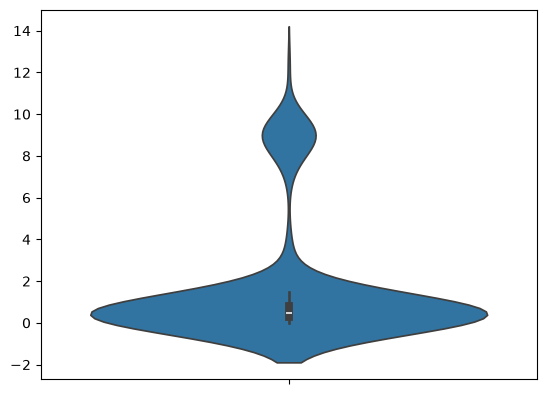

In [46]:
sns.violinplot(diff_list)

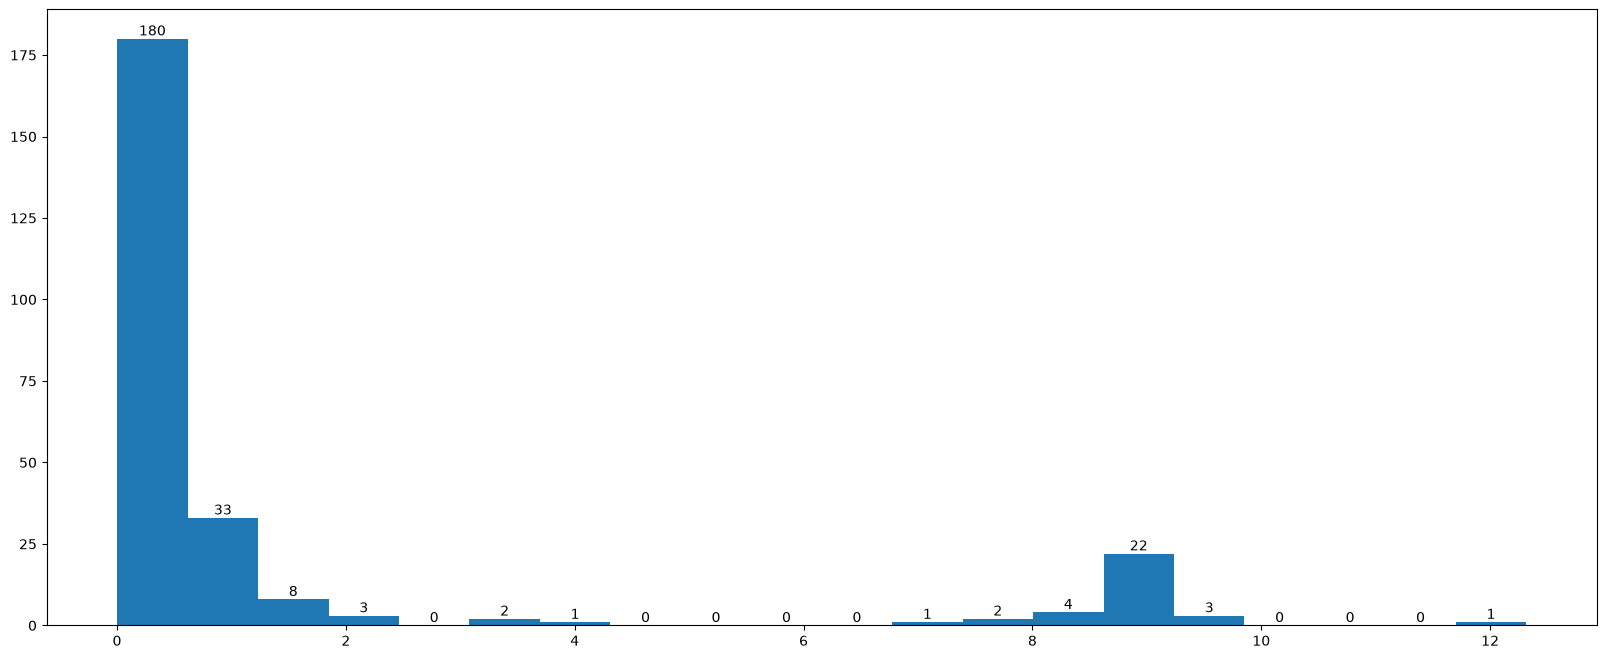

In [47]:
plt.figure(figsize=(20, 8))

cts, bins, patches = plt.hist(diff_list, bins=20)

for c, left, right in zip(cts, bins[:-1], bins[1:]):
    center = (left + right) / 2
    plt.text(center, c, f'{int(c)}',
             ha='center', va='bottom')

plt.show()

workouts on the same day separated by more than 5 hours are doubles --> keep separate
workouts on the same day separated by less than 5 hours are multiple segments of one workout --> collapse into one

In [48]:
print(diff_list.min())
print(diff_list.max())
print(np.median(diff_list))

0.0013888888888888887
12.315833333333334
0.45458333333333334


In [49]:
def agg_track_lines(series):
    lines = []
    for mline in series:
        lines.append(mline.geoms[0])
    return shapely.MultiLineString(lines)

rows = []
agg_dict = {
    "track_file": 'sum',
    "track_file_datetime": 'min',
    "start_datetime": 'first',
    "end_datetime": 'last',
    "year": 'first',
    "season": 'first',
    "total_duration": 'sum',
    "total_distance (mi)": 'sum',
    "average_pace (min/mi)": 'mean',
    "total_elevation_change (m)": 'sum',
    "in_stc": 'first',
    "start_point": 'first',
    "end_point": 'last',
    "track_line": agg_track_lines
}

for group_name, group in gdf_track_info.groupby("track_file_date"):
    split = group['start_datetime'].diff().apply(lambda x: x.total_seconds()/3600) > 5
    if split.sum() > 0:
        # add condensed first session
        rows.append(group[:split.argmax()].groupby("track_file_date").agg(agg_dict).reset_index())

        # add condensed second session
        rows.append(group[split.argmax():].groupby("track_file_date").agg(agg_dict).reset_index())
    else:
        # add condensed session
        rows.append(group.groupby("track_file_date").agg(agg_dict).reset_index())

In [50]:
cleaned_tracks = pd.concat(rows)
cleaned_tracks = gpd.GeoDataFrame(cleaned_tracks, geometry="track_line", crs="EPSG:4326")
cleaned_tracks["start_point"] = gpd.GeoSeries(cleaned_tracks["end_point"], crs=cleaned_tracks.crs)
cleaned_tracks["end_point"] = gpd.GeoSeries(cleaned_tracks["end_point"], crs=cleaned_tracks.crs)
# cleaned_tracks.to_parquet("../data/track_info_cleaned.parquet")
cleaned_tracks

,track_file_date,track_file,track_file_datetime,start_datetime,end_datetime,year,season,total_duration,total_distance (mi),average_pace (min/mi),total_elevation_change (m),in_stc,start_point,end_point,track_line
0,2019-06-10,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,Freshman,Summer Training,0 days 00:48:28,3.063156,8.542777,77.126862,True,POINT (-88.32166 41.9109),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215..."
0,2019-06-11,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,Freshman,Summer Training,0 days 00:33:20,3.172008,8.767494,122.178753,True,POINT (-88.34792 41.92783),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ..."
0,2019-06-12,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00,2019-06-12 11:53:30+00:00,2019-06-12 12:35:13+00:00,Freshman,Summer Training,0 days 00:41:43,3.052702,8.581829,132.038013,True,POINT (-88.32172 41.911),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32152 41.91252, -88.3215..."
0,2019-06-17,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,Freshman,Summer Training,0 days 00:30:00,2.983042,9.088904,86.000490,True,POINT (-88.32154 41.91096),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ..."
0,2019-06-18,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,Freshman,Summer Training,0 days 00:25:23,2.355063,9.380388,95.971917,True,POINT (-88.34797 41.92783),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,2023-05-03,/Users/ryansponzilli/Developer/Python Projects...,2023-05-03 15:31:00,2023-05-03 19:57:04+00:00,2023-05-03 20:31:52+00:00,Senior,Track Season,0 days 00:34:48,4.069221,7.555141,63.955394,True,POINT (-88.27995 41.92839),POINT (-88.27995 41.92839),"MULTILINESTRING ((-88.2791 41.92803, -88.27908..."
0,2023-05-04,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00,2023-05-04 19:54:31+00:00,2023-05-04 20:42:07+00:00,Senior,Track Season,0 days 00:33:42,3.031953,6.306000,32.264708,True,POINT (-88.27658 41.92851),POINT (-88.27658 41.92851),"MULTILINESTRING ((-88.27989 41.92867, -88.2798..."
0,2023-05-05,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00,2023-05-05 19:44:31+00:00,2023-05-05 20:11:23+00:00,Senior,Track Season,0 days 00:26:52,3.509378,6.976707,43.772437,True,POINT (-88.27952 41.9282),POINT (-88.27952 41.9282),"MULTILINESTRING ((-88.27988 41.92846, -88.2798..."
0,2023-05-06,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00,2023-05-06 15:58:42+00:00,2023-05-06 16:15:16+00:00,Senior,Track Season,0 days 00:16:34,1.985944,7.678578,38.987511,True,POINT (-88.32167 41.95012),POINT (-88.32167 41.95012),"MULTILINESTRING ((-88.32198 41.95005, -88.3219..."


In [ ]:
temp = gdf_track_info.groupby("track_file_date").get_group(counts.loc[counts["start_datetime"] > 1].iloc[132].name)
temp

KeyError: "None of [Index([1, 1, 1, 1, 1, 2, 3, 1, 1, 3,\n       ...\n       1, 1, 1, 1, 1, 1, 2, 1, 1, 1],\n      dtype='int64', name='track_file_date', length=763)] are in the [index]"